In [9]:
# (Run this first)
# If you don't have pandas/matplotlib installed, uncomment the pip line below:
# !pip install pandas matplotlib openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from pathlib import Path

# show plots inline
%matplotlib inline

# Output folder to save cleaned data and images
out_dir = Path("mobiles_analysis_outputs")
out_dir.mkdir(exist_ok=True)

In [15]:
# Update file_path if your CSV is in a different location
file_path = "Mobiles Dataset (2025)--.csv"

# Try default encoding then fallback to latin1 if needed
try:
   df = pd.read_csv(r"C:\Users\guddi\OneDrive\文档\GOURI\Data Analyst course\Minor project\Mobiles Dataset (2025).csv", encoding="latin-1")

except UnicodeDecodeError:
    df = pd.read_csv(file_path, encoding='latin1')

print("Rows, Columns:", df.shape)
df.head()

Rows, Columns: (930, 15)


,Company Name,Model Name,Mobile Weight,RAM,Front Camera,Back Camera,Processor,Battery Capacity,Screen Size,Launched Price (Pakistan),Launched Price (India),Launched Price (China),Launched Price (USA),Launched Price (Dubai),Launched Year
0,Apple,iPhone 16 128GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,"PKR 224,999","INR 79,999","CNY 5,799",USD 799,"AED 2,799",2024
1,Apple,iPhone 16 256GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,"PKR 234,999","INR 84,999","CNY 6,099",USD 849,"AED 2,999",2024
2,Apple,iPhone 16 512GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,"PKR 244,999","INR 89,999","CNY 6,499",USD 899,"AED 3,199",2024
3,Apple,iPhone 16 Plus 128GB,203g,6GB,12MP,48MP,A17 Bionic,"4,200mAh",6.7 inches,"PKR 249,999","INR 89,999","CNY 6,199",USD 899,"AED 3,199",2024
4,Apple,iPhone 16 Plus 256GB,203g,6GB,12MP,48MP,A17 Bionic,"4,200mAh",6.7 inches,"PKR 259,999","INR 94,999","CNY 6,499",USD 949,"AED 3,399",2024


In [17]:
# Basic info
df.info()

# Basic numeric summary (may be empty until we parse numeric fields)
df.describe(include='all').T

# Missing values count per column
(df.isna().sum().sort_values(ascending=False)).head(20)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 930 entries, 0 to 929
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Company Name               930 non-null    object
 1   Model Name                 930 non-null    object
 2   Mobile Weight              930 non-null    object
 3   RAM                        930 non-null    object
 4   Front Camera               930 non-null    object
 5   Back Camera                930 non-null    object
 6   Processor                  930 non-null    object
 7   Battery Capacity           930 non-null    object
 8   Screen Size                930 non-null    object
 9   Launched Price (Pakistan)  930 non-null    object
 10  Launched Price (India)     930 non-null    object
 11  Launched Price (China)     930 non-null    object
 12  Launched Price (USA)       930 non-null    object
 13  Launched Price (Dubai)     930 non-null    object
 14  Launched Y

Company Name                 0
Model Name                   0
Mobile Weight                0
RAM                          0
Front Camera                 0
Back Camera                  0
Processor                    0
Battery Capacity             0
Screen Size                  0
Launched Price (Pakistan)    0
Launched Price (India)       0
Launched Price (China)       0
Launched Price (USA)         0
Launched Price (Dubai)       0
Launched Year                0
dtype: int64

In [21]:
def parse_gb(x):
    if pd.isna(x): return np.nan
    s = str(x)
    m = re.search(r'(\d+(\.\d+)?)\s*(GB|G|gb)\b', s, re.IGNORECASE)
    if m: return float(m.group(1))
    m2 = re.search(r'(\d+(\.\d+)?)', s)
    if m2: return float(m2.group(1))
    return np.nan

def parse_weight(x):
    if pd.isna(x): return np.nan
    s = str(x)
    m = re.search(r'(\d+(\.\d+)?)\s*(g|grams)\b', s, re.IGNORECASE)
    if m: return float(m.group(1))
    m2 = re.search(r'(\d+(\.\d+)?)', s)
    return float(m2.group(1)) if m2 else np.nan

def parse_mah(x):
    if pd.isna(x): return np.nan
    s = str(x).replace(',', '')
    m = re.search(r'(\d{3,6})\s*mAh', s, re.IGNORECASE)
    if m: return float(m.group(1))
    m2 = re.search(r'(\d{3,6})', s)
    return float(m2.group(1)) if m2 else np.nan

def parse_inches(x):
    if pd.isna(x): return np.nan
    s = str(x)
    # handle 6.1 inches or 6.1"
    m = re.search(r'(\d+(\.\d+)?)\s*(inches|inch|in|")', s, re.IGNORECASE)
    if m: return float(m.group(1))
    m2 = re.search(r'(\d+(\.\d+)?)', s)
    return float(m2.group(1)) if m2 else np.nan

def parse_price(x):
    if pd.isna(x): return np.nan
    s = str(x).replace('\xa0',' ')
    # find first number-like group (allow commas and decimals)
    m = re.search(r'(\d{1,3}(?:[,\d]*)(?:\.\d+)?)', s)
    if m:
        num = m.group(1).replace(',', '')
        try:
            return float(num)
        except:
            return np.nan
    return np.nan


In [23]:
# Make a working copy
data = df.copy()

# Optional: strip whitespace from object/string columns
for c in data.select_dtypes(include='object').columns:
    data[c] = data[c].astype(str).str.strip()

# Apply parsers (use the exact column names from your CSV)
# If a column doesn't exist in your CSV, wrap in try/except or check column list
cols = data.columns.tolist()
print("Columns found:", cols)

# Adjust these names to match your CSV column names if different
data['RAM_GB'] = data.get('RAM', pd.Series()).apply(parse_gb)
data['Weight_g'] = data.get('Mobile Weight', pd.Series()).apply(parse_weight)
data['Battery_mAh'] = data.get('Battery Capacity', pd.Series()).apply(parse_mah)
data['Screen_in'] = data.get('Screen Size', pd.Series()).apply(parse_inches)

data['Price_PKR'] = data.get('Launched Price (Pakistan)', pd.Series()).apply(parse_price)
data['Price_INR'] = data.get('Launched Price (India)', pd.Series()).apply(parse_price)
data['Price_CNY'] = data.get('Launched Price (China)', pd.Series()).apply(parse_price)
data['Price_USD'] = data.get('Launched Price (USA)', pd.Series()).apply(parse_price)
data['Price_AED'] = data.get('Launched Price (Dubai)', pd.Series()).apply(parse_price)

# Convert year to numeric
if 'Launched Year' in data.columns:
    data['Launched Year'] = pd.to_numeric(data['Launched Year'], errors='coerce')

# Quick check
data[['RAM','RAM_GB','Mobile Weight','Weight_g','Battery Capacity','Battery_mAh',
      'Screen Size','Screen_in','Launched Price (India)','Price_INR']].head(8)


Columns found: ['Company Name', 'Model Name', 'Mobile Weight', 'RAM', 'Front Camera', 'Back Camera', 'Processor', 'Battery Capacity', 'Screen Size', 'Launched Price (Pakistan)', 'Launched Price (India)', 'Launched Price (China)', 'Launched Price (USA)', 'Launched Price (Dubai)', 'Launched Year']


,RAM,RAM_GB,Mobile Weight,Weight_g,Battery Capacity,Battery_mAh,Screen Size,Screen_in,Launched Price (India),Price_INR
0,6GB,6.0,174g,174.0,"3,600mAh",3600.0,6.1 inches,6.1,"INR 79,999",79999.0
1,6GB,6.0,174g,174.0,"3,600mAh",3600.0,6.1 inches,6.1,"INR 84,999",84999.0
2,6GB,6.0,174g,174.0,"3,600mAh",3600.0,6.1 inches,6.1,"INR 89,999",89999.0
3,6GB,6.0,203g,203.0,"4,200mAh",4200.0,6.7 inches,6.7,"INR 89,999",89999.0
4,6GB,6.0,203g,203.0,"4,200mAh",4200.0,6.7 inches,6.7,"INR 94,999",94999.0
5,6GB,6.0,203g,203.0,"4,200mAh",4200.0,6.7 inches,6.7,"INR 104,999",104999.0
6,6GB,6.0,206g,206.0,"4,400mAh",4400.0,6.1 inches,6.1,"INR 99,999",99999.0
7,8GB,8.0,206g,206.0,"4,400mAh",4400.0,6.1 inches,6.1,"INR 104,999",104999.0


In [25]:
clean_csv = out_dir / "mobiles_cleaned.csv"
clean_xlsx = out_dir / "mobiles_cleaned_for_powerbi.xlsx"
data.to_csv(clean_csv, index=False)
data.to_excel(clean_xlsx, index=False)
print("Saved:", clean_csv, "\nSaved:", clean_xlsx)


Saved: mobiles_analysis_outputs\mobiles_cleaned.csv 
Saved: mobiles_analysis_outputs\mobiles_cleaned_for_powerbi.xlsx


In [27]:
# Number of unique brands and models
n_brands = data['Company Name'].nunique() if 'Company Name' in data.columns else None
n_models = data['Model Name'].nunique() if 'Model Name' in data.columns else None
print("Unique brands:", n_brands, "Unique models:", n_models)

# Brand counts
brand_counts = data['Company Name'].value_counts().reset_index()
brand_counts.columns = ['Company Name','Count']
brand_counts.head(20)

# Brand price summary (INR)
brand_price_inr = (
    data.groupby('Company Name')['Price_INR']
    .agg(['count','mean','median','min','max'])
    .reset_index()
    .sort_values('mean', ascending=False)
)
brand_price_inr.head(20)

# Specification summary
spec_summary = data[['RAM_GB','Weight_g','Battery_mAh','Screen_in','Price_INR']].describe().round(2)
spec_summary


Unique brands: 19 Unique models: 908


,RAM_GB,Weight_g,Battery_mAh,Screen_in,Price_INR
count,930.00,930.00,930.00,930.00,930.00
mean,7.78,228.27,5026.16,7.08,50576.82
std,3.18,105.43,1355.55,1.53,40960.18
min,1.00,135.00,2000.00,5.00,5999.00
25%,6.00,185.00,4402.50,6.50,19999.00
50%,8.00,194.00,5000.00,6.67,34999.00
75%,8.00,208.00,5091.25,6.78,74900.00
max,16.00,732.00,11200.00,14.60,274999.00


In [29]:
# Top 10 by battery
top_battery = data.sort_values('Battery_mAh', ascending=False)[['Company Name','Model Name','Battery_mAh','Price_INR']].head(10)
top_battery

# Top 10 by RAM
top_ram = data.sort_values('RAM_GB', ascending=False)[['Company Name','Model Name','RAM_GB','Price_INR']].head(10)
top_ram

# Top 10 most expensive (INR)
top_price = data.sort_values('Price_INR', ascending=False)[['Company Name','Model Name','Price_INR','RAM_GB','Battery_mAh']].head(10)
top_price


,Company Name,Model Name,Price_INR,RAM_GB,Battery_mAh
661,Huawei,Mate XT 512GB,274999.0,12.0,5000.0
660,Huawei,Mate XT 256GB,259999.0,12.0,5000.0
643,Huawei,Mate X3,249999.0,12.0,4800.0
630,Huawei,Mate X2,249999.0,8.0,4500.0
657,Huawei,Mate X6,249999.0,12.0,4800.0
929,Samsung,Galaxy Z Fold6 1TB,200999.0,12.0,4400.0
634,Huawei,Mate Xs 2,199999.0,8.0,4600.0
96,Apple,iPad Pro 13-inch 2TB,199900.0,6.0,10307.0
708,Google,Pixel 9 Pro Fold 512GB,179999.0,16.0,5500.0
95,Apple,iPad Pro 13-inch 1TB,179900.0,6.0,10307.0


In [31]:
numeric_cols = ['RAM_GB','Weight_g','Battery_mAh','Screen_in','Price_INR','Price_USD','Launched Year']
corrs = data[numeric_cols].corr().round(2)
corrs

,RAM_GB,Weight_g,Battery_mAh,Screen_in,Price_INR,Price_USD,Launched Year
RAM_GB,1.00,-0.01,0.14,0.05,0.42,0.11,0.38
Weight_g,-0.01,1.00,0.85,0.98,0.14,0.10,0.07
Battery_mAh,0.14,0.85,1.00,0.88,-0.01,0.06,0.35
Screen_in,0.05,0.98,0.88,1.00,0.11,0.10,0.14
Price_INR,0.42,0.14,-0.01,0.11,1.00,0.28,0.07
Price_USD,0.11,0.10,0.06,0.10,0.28,1.00,0.01
Launched Year,0.38,0.07,0.35,0.14,0.07,0.01,1.00


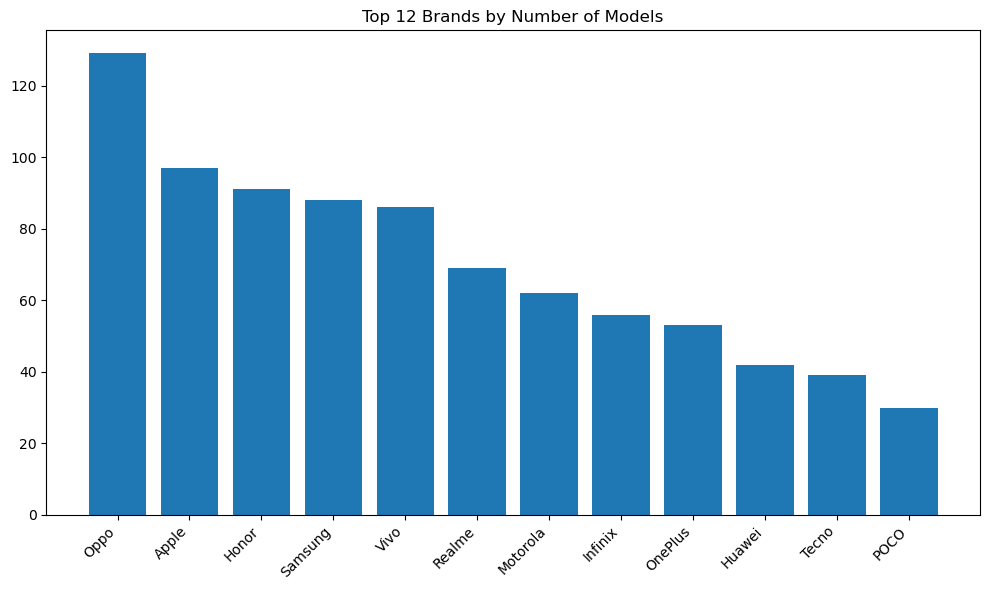

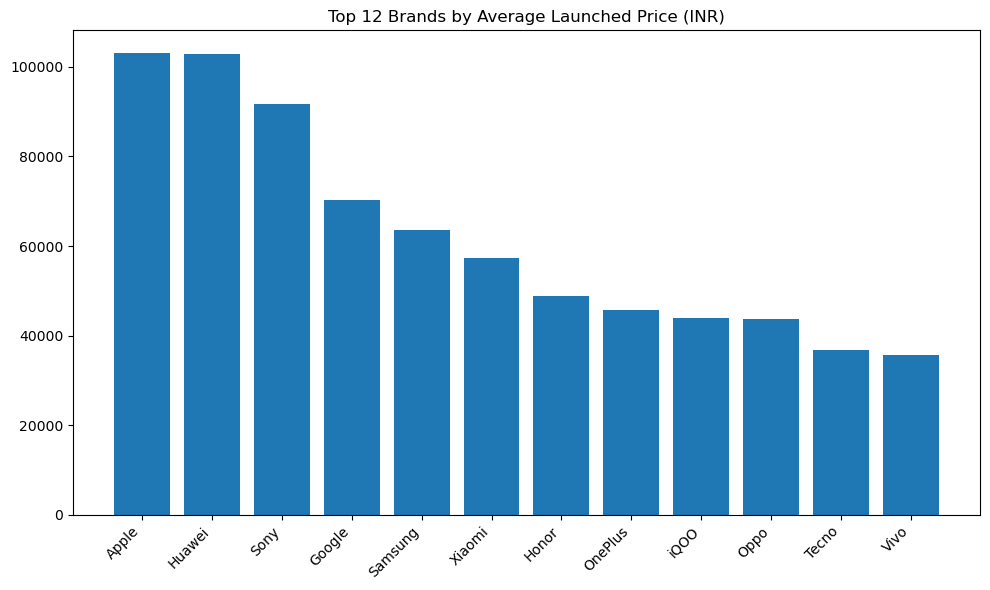

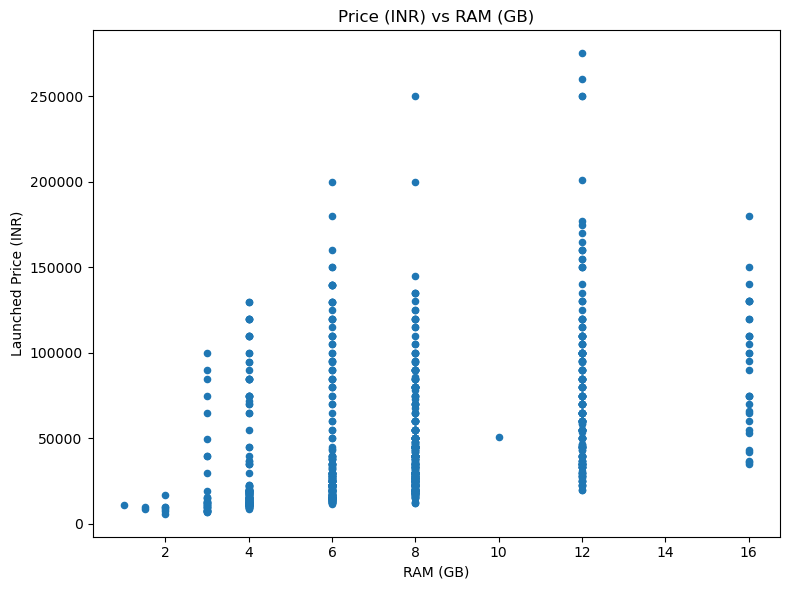

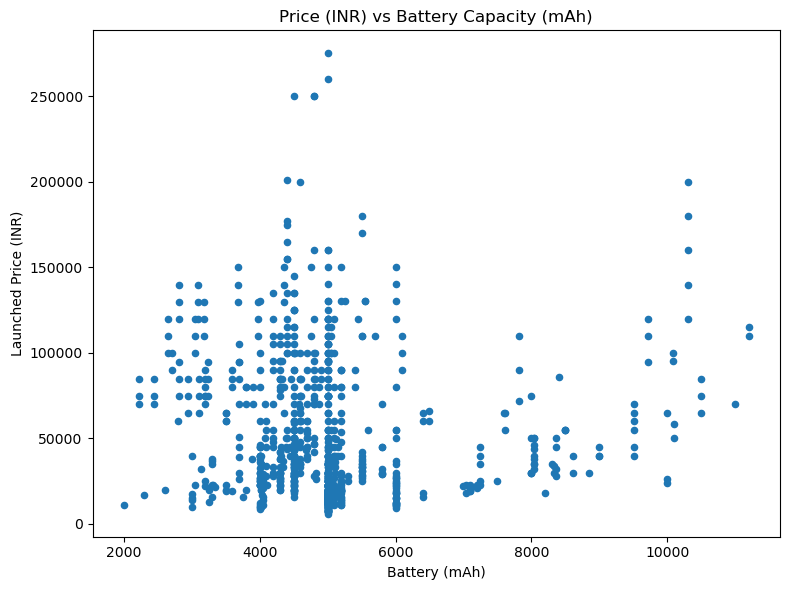

C:\Users\guddi\AppData\Local\Temp\ipykernel_33932\2268518449.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxdata, labels=top6)


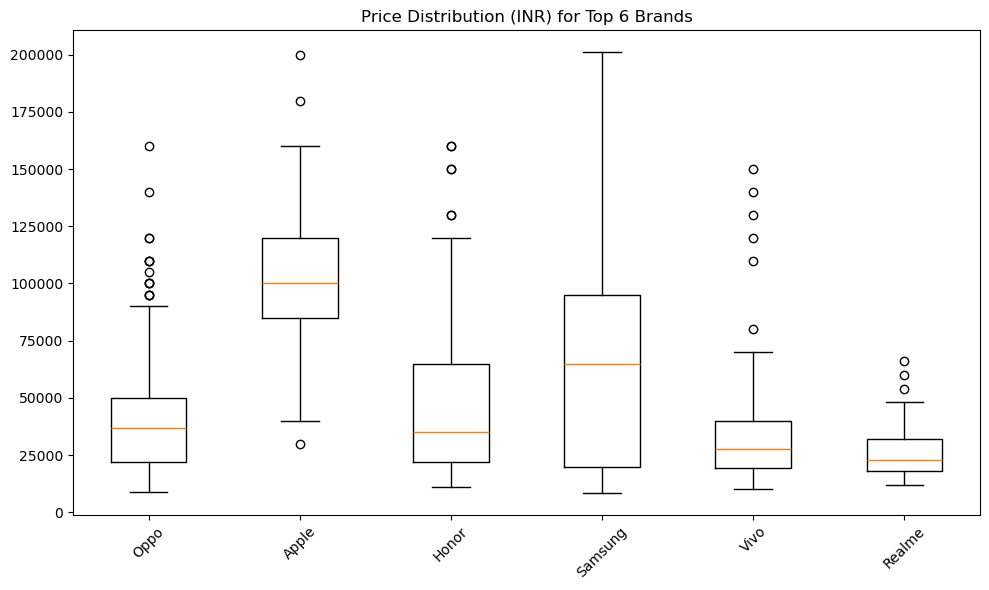

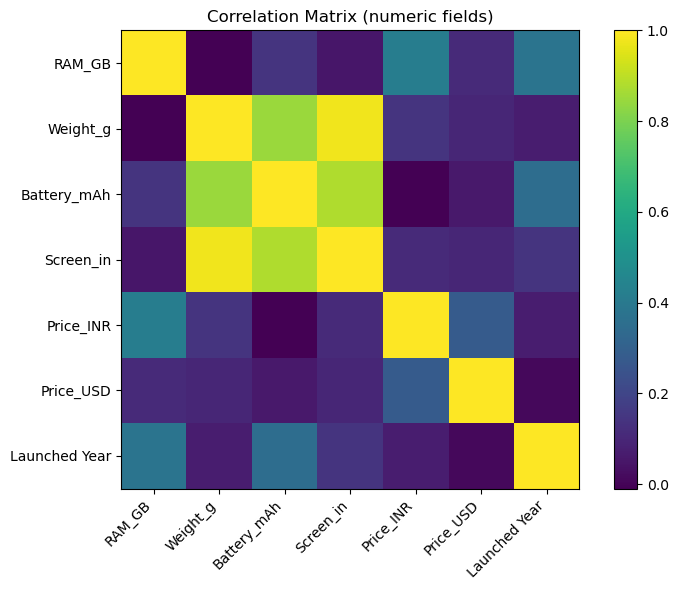

In [33]:
# 1) Top 12 brands by model count (bar)
plt.figure(figsize=(10,6))
top_brands = brand_counts.head(12)
plt.bar(top_brands['Company Name'], top_brands['Count'])
plt.xticks(rotation=45, ha='right')
plt.title('Top 12 Brands by Number of Models')
plt.tight_layout()
plt.savefig(out_dir / "top_brands_count.png")
plt.show()

# 2) Top 12 brands by average launched price (INR)
plt.figure(figsize=(10,6))
bp = brand_price_inr.head(12)
plt.bar(bp['Company Name'], bp['mean'])
plt.xticks(rotation=45, ha='right')
plt.title('Top 12 Brands by Average Launched Price (INR)')
plt.tight_layout()
plt.savefig(out_dir / "avg_price_by_brand_inr.png")
plt.show()

# 3) Scatter: Price (INR) vs RAM (GB)
plt.figure(figsize=(8,6))
subset = data.dropna(subset=['Price_INR','RAM_GB'])
plt.scatter(subset['RAM_GB'], subset['Price_INR'], s=20)
plt.xlabel('RAM (GB)')
plt.ylabel('Launched Price (INR)')
plt.title('Price (INR) vs RAM (GB)')
plt.tight_layout()
plt.savefig(out_dir / "price_vs_ram.png")
plt.show()

# 4) Scatter: Price (INR) vs Battery (mAh)
plt.figure(figsize=(8,6))
subset2 = data.dropna(subset=['Price_INR','Battery_mAh'])
plt.scatter(subset2['Battery_mAh'], subset2['Price_INR'], s=20)
plt.xlabel('Battery (mAh)')
plt.ylabel('Launched Price (INR)')
plt.title('Price (INR) vs Battery Capacity (mAh)')
plt.tight_layout()
plt.savefig(out_dir / "price_vs_battery.png")
plt.show()

# 5) Boxplot: Price distribution for top 6 brands (INR)
plt.figure(figsize=(10,6))
top6 = brand_counts.head(6)['Company Name'].tolist()
boxdata = [data.loc[data['Company Name']==b,'Price_INR'].dropna() for b in top6]
plt.boxplot(boxdata, labels=top6)
plt.title('Price Distribution (INR) for Top 6 Brands')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(out_dir / "price_boxplot_top6.png")
plt.show()

# 6) Correlation matrix (imshow)
plt.figure(figsize=(8,6))
corr_subset = corrs.fillna(0)
plt.imshow(corr_subset)
plt.colorbar()
plt.xticks(range(len(corr_subset.columns)), corr_subset.columns, rotation=45, ha='right')
plt.yticks(range(len(corr_subset.index)), corr_subset.index)
plt.title('Correlation Matrix (numeric fields)')
plt.tight_layout()
plt.savefig(out_dir / "correlation_matrix.png")
plt.show()


In [1]:
plt.figure(figsize=(10,6))
top_brands = brand_counts.head(12)
plt.bar(top_brands['Company Name'], top_brands['Count'])
plt.xticks(rotation=45, ha='right')
plt.title('Top 12 Brands by Number of Models')
plt.tight_layout()
plt.savefig(out_dir / "top_brands_count.png")
plt.show()


NameError: name 'plt' is not defined

In [35]:
brand_counts.to_csv(out_dir / "brand_counts.csv", index=False)
brand_price_inr.to_csv(out_dir / "brand_price_inr_summary.csv", index=False)
top_battery.to_csv(out_dir / "top_battery_models.csv", index=False)
print("Saved summary CSVs to", out_dir)


Saved summary CSVs to mobiles_analysis_outputs


In [37]:
# create RAM buckets (example)
bins = [0,2,4,6,8,12,16,32,64,256]
labels = ['<=2','3-4','5-6','7-8','9-12','13-16','17-32','33-64','65+']
data['RAM_bucket'] = pd.cut(data['RAM_GB'], bins=bins, labels=labels, include_lowest=True)

# Count models per year
launch_by_year = data.groupby('Launched Year').size().reset_index(name='count').sort_values('Launched Year')
launch_by_year


,Launched Year,count
0,2014,2
1,2016,5
2,2017,9
3,2018,21
4,2019,46
5,2020,101
6,2021,109
7,2022,149
8,2023,184
9,2024,292
